Resumen: 
- Implementacion:
    - Training: noiseless, noisy y real
    - Evaluation: noiseless y noisy
- Simulación via qiskit_aer (en GPUs)
- Optimicación pytorch para evaluacion en multiples GPUs

Embedding:
- Angle embedding
- Batch parallelization via qiskit_aer pubs. Fake pubs in EstimatorQNN, Real pubs without EstimatorQNN.

## Implementation (statevector simulation)

In [71]:
#--- INSTALATION INSTRUCTIONS ---#

# For linux 64-bit systems,
#uname -a

# Conda quick installation
#mkdir -p ~/miniconda3
#wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda3/miniconda.sh
#bash ~/miniconda3/miniconda.sh -b -u -p ~/miniconda3
#rm ~/miniconda3/miniconda.sh

# Create enviroment with conda
#conda create -n myenv python=3.10
#conda activate myenv
#pip install qiskit qiskit-machine-learning 'qiskit-machine-learning[sparse]' qiskit_aer qiskit-aer-gpu qiskit_algorithms torch matplotlib pylatexenc ipykernelc
# IMPORTANT: Make sure you are on 3.10
# May need to restart the kernel after instalation

#--- Imports ---#
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.quantum_info import random_statevector, Statevector, SparsePauliOp
from qiskit.circuit.library import real_amplitudes, efficient_su2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import qpy

from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient, SPSAEstimatorGradient
from qiskit_machine_learning.connectors import TorchConnector

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2 as EstimatorV2_sim, SamplerV2 as SamplerV2_sim
from qiskit_aer.quantum_info import AerStatevector
from qiskit_aer.library import SaveProbabilities

from qiskit_ibm_runtime import EstimatorV2 as EstimatorV2_rh, QiskitRuntimeService, Session
from qiskit_ibm_runtime.options import EstimatorOptions

from qiskit_algorithms.gradients import ReverseEstimatorGradient

import numpy as np
import torch
import matplotlib.pyplot as plt
import time
import os
import signal
import datetime as dt
import pickle

In [72]:
#- Configuration -#

# Training configuration dict
train_config = {
    'execution_type': "noisy", # 'noiseless', 'noisy' or 'real'
    'n_qubits': 4,
    'seed': 0,
    'id': None, # For different circuits or training parameters
    
    # Data
    'reset_data': True,
    'create_circuits': True, # Create circuits or load from file

    # Training parameters
    'max_iterations': 1000,
    'gen_iterations': 1,
    'disc_iterations': 3,
    'print_progress_iterations': 1,

    # Compute methods
    'device': "CPU", # 'GPU' or 'CPU'
    'gradient_method': "SPSA", # qiskit_algorithms.gradients For now: 'PSR', 'SPSA' and 'REG'

    # Angle embedding
    'batch_size': 4, # How many samples' gradients are going to be calculated in a step
    #'real_rate': 0.5, # Rate of training discriminator with real samples instead of generated samples
    'random_input': True, # Add randomness in the input when generating a sample

    # File names
    'training_data_file': None, # If all None, automatically created with manage_files function
    'circuits_file': None,
    'backend_file': None,
    'dataset_file': None

}


# File management
def manage_files(
        data_folder_name = 'data', 
        implementation_name = 'torchc_ang', 
        execution_type_name = train_config['execution_type'], 
        training_data_file_name = 'training_data', 
        circuits_file_name = 'circuits', 
        backend_file_name = 'backend',
        dataset_file_name = 'dataset'
        ):
    
    data_folder = data_folder_name + '/' + implementation_name + '/' + execution_type_name + '/' + 'q' + str(train_config['n_qubits']) + '/' + 'seed' + str(train_config['seed']) + '/'
    if train_config['id'] is not None:
        data_folder = data_folder + '/' + str(train_config['id']) + '/' 
    training_data_file = data_folder + training_data_file_name + '.pth'
    circuits_file = data_folder + circuits_file_name + '.qpy'
    backend_file = data_folder + backend_file_name + '.pkl'
    dataset_file = data_folder + dataset_file_name + '.npy'

    # Create folders if they do not exist
    if not os.path.exists(data_folder):
        os.makedirs(data_folder)

    return training_data_file, circuits_file, backend_file, dataset_file



if ((train_config['training_data_file'] is None) and (train_config['circuits_file'] is None) and (train_config['backend_file'] is None) and (train_config['dataset_file'] is None)):
    train_config['training_data_file'], train_config['circuits_file'], train_config['backend_file'], train_config['dataset_file'] = manage_files()

In [73]:
#- Backend configuration -#

# Get shots from precision
def get_shots(precision):
    if np.isclose(precision, 0, atol=1e-8):
        return None
    else:
        return int(1/(precision**2))


# Backend configuration
backend_config = {
    # Real backend
    'name': "ibm_basquecountry",
    'channel': "ibm_quantum_platform",

    # Noisy backend
    'reset_backend': False, # Get current backend state or load from file
    'timestamp': dt.datetime.now(),

    # Noiseless/Noiseless backend
    'sim_options': {
        'method': 'automatic', # If None, use defalut options (los de abajo)
        'precision': "double", # 'single' or 'double'. Also used to choose torch dtype
        'seed_simulator': train_config['seed']
    },
}

# Backend predefined configuration for GPU cuda execution
if train_config["device"] == "GPU":
    backend_config['sim_options'].update({
        'device': 'GPU', # For nvidia cuda

        'cuStateVec_enable': True,   # NVIDIA library optimization
        'batched_shots_gpu': True,   # Parallelize batch on GPU
        'blocking_enable': False,     # Disable chunking; simulation fits in VRAM 
        #'target_gpus':[0,1], # TODO import torch after? In .py read how many after printing aviables?

        'runtime_parameter_bind_enable': True, # tells Aer to keep the circuit parameterized and bind the numeric values at execution time TODO prueba pa saber las mejores options
    })

# Backend predefined configuration for noise
if train_config["execution_type"] in ["noisy", "real"]:
    backend_config['sim_options']['method'] = 'density_matrix'
    backend_config['train_precision'] = 0.015625
    backend_config['eval_precision'] = 0.0
else:
    backend_config['sim_options']['method'] = 'statevector'
    backend_config['train_precision'] = 0.0
    backend_config['eval_precision'] = 0.0 # Not fully TorchConnector: precision cannot be 0 because of Aer SamplerV2
backend_config['sim_options']['shots'] = get_shots(backend_config["train_precision"])
'''
method:
    For noiseless execution:
        - statevector
        - matrix_product_state: more qubits, low entanglement
    For noisy execution:
        - density_matrix
        - statevector: uses less memory
    - stabilizer: only for Clifford circuits (only H, CNOT, and S gates)
    - tensor_network: for large circuits (when reaching memory limits, only GPU)
'''

'''
# More options
backend_for_info = AerSimulator()
print("AerSimulator backend configuration options:")
for option in backend_for_info.options:
    print(" -", option)

'''



# # Save account
# QiskitRuntimeService.save_account(
#     token="",
#     instance="crn:v1:bluemix:public:quantum-computing:eu-de:a/cb804b30dfcb48b890393bfd6e41e9c2:4cb40c64-a531-4c13-b39c-e04c31185259::",
#     set_as_default = True,
#     overwrite=True
# )



# Save current backend
def reset_backend():
    if train_config['execution_type'] in ["noisy", "real"]:
        service = QiskitRuntimeService(channel=backend_config['channel']) # Real backend    #job.properties().to_dict() to save real hardware state during training TODO
        real_backend = service.backend(backend_config['name']) #backend = service.least_busy(min_num_qubits=30)
        backend = AerSimulator.from_backend(real_backend, **backend_config['sim_options']) # Get current backend state
    else:
        backend = AerSimulator(**backend_config['sim_options'])

    backend_dict = {
        'timestamp': dt.datetime.now(dt.timezone.utc),
        'configuration': backend.configuration(),
        'properties': backend.properties(),
        'target': backend.target,
        'options': backend.options,
        'noise_model': None if train_config["execution_type"] == "noiseless" else backend.options.noise_model
    }

    with open(train_config['backend_file'], "wb") as f:
        pickle.dump(backend_dict, f)


# Reset backend file
if backend_config['reset_backend']:
    reset_backend()


# Create backend
if train_config['execution_type'] == "real": # TODO guardar otras configuraciones del backend real?
    service = QiskitRuntimeService(channel=backend_config['channel']) # Real backend
    real_backend = service.backend(backend_config['name']) #backend = service.least_busy(min_num_qubits=30)
    backend = real_backend
    session = Session(backend=backend)
    # TODO qiskit-ibm-runtime

else:
    # Load backend configuration
    try:
        with open(train_config['backend_file'], "rb") as f:
            backend_dict = pickle.load(f)
    except FileNotFoundError:
        print("Backend data file not found. Resetting backend configuration.")
        reset_backend()
        with open(train_config['backend_file'], "rb") as f:
            backend_dict = pickle.load(f)


    # Create backend
    backend = AerSimulator(
        configuration=backend_dict['configuration'],
        properties=backend_dict['properties'],
        target=backend_dict['target'],
        **backend_dict['options']
    )


    # Create Estimator for simulation
    estimator = EstimatorV2_sim(
        options = {
            "default_precision": backend_config["train_precision"],
            "backend_options": backend.options,
        })


# Transpilation method
pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    seed_transpiler=train_config['seed']
)



# Backend, estimator and pm for noiseless evaluation (do not need to execute evaluation in a nosiy environment)
eval_backend = AerSimulator(**backend_config['sim_options'])
eval_estimator = EstimatorV2_sim(options = {"default_precision": backend_config["eval_precision"], "backend_options": eval_backend.options,})
eval_pm = generate_preset_pass_manager(optimization_level=3, backend=eval_backend, seed_transpiler=train_config['seed'])



# Select device torch
#os.environ["CUDA_VISIBLE_DEVICES"] = "1,2" # before torch import to select specific devices
#import torch
if train_config['device'] == "GPU" and torch.cuda.is_available():
    print(f"GPUs available to PyTorch: {torch.cuda.device_count()}")
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

if backend_config["sim_options"]["precision"] == "double":
    dtype = torch.float64
else:
    dtype = torch.float32


# Print backend properties
print(backend)

AerSimulator('aer_simulator_from(ibm_basquecountry)'
             noise_model=<NoiseModel on ['measure', 'x', 'sx', 'id', 'reset', 'cz']>)


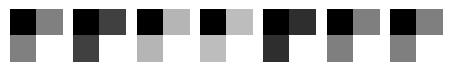

dataset shape: torch.Size([7, 2, 2]) 
data type: torch.float64


In [74]:
#- Load dataset -#

# Build my own dataset of images: gradient images
def apply_curve(x, curve):
    if curve == 'linear':
        return x
    elif curve == 'quadratic':
        return x ** 2
    elif curve == 'sqrt':
        return np.sqrt(x)
    elif curve == 'log':
        return np.log1p(x * 9) / np.log(10)  # scale [0,1] into [0,1] log space
    elif curve == 'exp':
        return (np.exp(x * 3) - 1) / (np.exp(3) - 1)  # normalized exponential
    elif curve == 'sigmoid':
        return 1 / (1 + np.exp(-10 * (x - 0.5)))  # smooth S-curve
    elif curve == 'sin':
        return 0.5 * (1 - np.cos(np.pi * x))  # smooth start and end
    else:
        raise ValueError(f"Unknown curve type: {curve}")

def create_gradients(total_pixels, directions=None, curves=None, width=None, height=None):
    if directions is None:
        directions = [
            'top_left_to_bottom_right'
        ]
    if curves is None:
        curves = ['linear', 'quadratic', 'sqrt', 'log', 'exp', 'sigmoid', 'sin']

    if width is None or height is None:
        for h in range(int(np.sqrt(total_pixels)), 0, -1):
            if total_pixels % h == 0:
                width, height = total_pixels // h, h
                break
    elif width * height != total_pixels:
        raise ValueError("Provided width and height do not match total number of pixels.")

    max_val = 255
    gradients = []

    i, j = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

    # Precompute normalized coordinate matrices for all directions
    norm_maps = {
        'left_to_right': np.tile(np.linspace(0, 1, width), (height, 1)),
        'right_to_left': np.tile(np.linspace(1, 0, width), (height, 1)),
        'top_to_bottom': np.tile(np.linspace(0, 1, height)[:, np.newaxis], (1, width)),
        'bottom_to_top': np.tile(np.linspace(1, 0, height)[:, np.newaxis], (1, width)),
        'top_left_to_bottom_right': (i + j) / (width + height - 2),
        'bottom_right_to_top_left': ((height - 1 - i) + (width - 1 - j)) / (width + height - 2),
        'top_right_to_bottom_left': (i + (width - 1 - j)) / (width + height - 2),
        'bottom_left_to_top_right': ((height - 1 - i) + j) / (width + height - 2)
    }

    for direction in directions:
        if direction not in norm_maps:
            raise ValueError(f"Unknown direction: {direction}")
        base_map = norm_maps[direction]

        for curve in curves:
            # Apply curve to normalized map
            curved_map = apply_curve(base_map, curve)
            gradients.append(curved_map)

    # Save in file
    image_array = np.array(gradients).reshape(-1, height, width)
    np.save(train_config['dataset_file'], image_array)


# Load circuits from file
try:
    X = np.load(train_config['dataset_file'])
except FileNotFoundError:
    print("Dataset file not found. Creating new dataset file.")
    create_gradients(train_config['n_qubits'])
    X = np.load(train_config['dataset_file'])

X = torch.as_tensor(X, device=device, dtype=dtype)

# Show dataset
for i in range(len(X)):
    plt.subplot(1,len(X)+1,i+1)
    plt.imshow(X[i].detach().cpu(), cmap="gray")
    plt.axis("off")
plt.show()
print("dataset shape:", X.shape, "\ndata type:", X.dtype)

In [75]:
#- Angle embedding -#

# Create real data sample circuit
def generate_real_circuit():
    n_qubits = train_config['n_qubits']

    real_weights = ParameterVector('θ_r', n_qubits)
    qc = QuantumCircuit(n_qubits, name="Real circuit")
    param_index = 0

    for q in range(n_qubits):
        qc.ry(real_weights[param_index], q); param_index += 1

    return qc

In [76]:
#- Create quantum circuits -#

# Create generator
def generate_generator():
    n_qubits = train_config['n_qubits']

    qc = real_amplitudes(n_qubits,
                        reps=3, # Number of layers
                        parameter_prefix='θ_g',
                        name='Generator')
    
    return qc.decompose()


# Create discriminator
def generate_discriminator():
    n_qubits = train_config['n_qubits']

    qc = efficient_su2(n_qubits,
                      entanglement="reverse_linear",
                      reps=1, # Number of layers
                      parameter_prefix='θ_d',
                      name='Discriminator').decompose()


    param_index = qc.num_parameters

    for i in reversed(range(n_qubits - 1)):
        qc.cx(i, n_qubits - 1)

    #qc.rx(disc_weights[param_index], N_QUBITS-1); param_index += 1
    qc.ry(Parameter("θ_d["+str(param_index)+"]"), n_qubits-1); param_index += 1
    qc.rz(Parameter("θ_d["+str(param_index)+"]"), n_qubits-1); param_index += 1
    
    return qc


# Create quantum circuits
def create_circuits():
    real_circuit = generate_real_circuit()
    generator_circuit = generate_generator()
    discriminator_circuit = generate_discriminator()

    # Save circuits in a file
    with open(train_config['circuits_file'], 'wb') as fd:
        qpy.dump([real_circuit, generator_circuit, discriminator_circuit], fd)


# Rewrite circuits file if indicated in options
if train_config['create_circuits']:
    create_circuits()


# Load circuits from file
try:
    with open(train_config['circuits_file'], 'rb') as fd:
        circuits = qpy.load(fd)
except FileNotFoundError:
    print("Circuits file not found. Creating new circuits file.")
    create_circuits()
    with open(train_config['circuits_file'], 'rb') as fd:
        circuits = qpy.load(fd)
    
    
real_circuit = circuits[0]
generator_circuit = circuits[1]
discriminator_circuit = circuits[2]

In [77]:
#- Set up training quantum circuits -#
def generate_training_circuits(real_circuit, generator_circuit, discriminator_circuit):
    n_qubits = train_config['n_qubits']

    # Connect real data and discriminator
    real_disc_circuit = QuantumCircuit(n_qubits)
    real_disc_circuit.compose(real_circuit, inplace=True)
    real_disc_circuit.compose(discriminator_circuit, inplace=True)

    # Connect real circuit to generator and discriminator for random input
    ran_gen_circuit = QuantumCircuit(n_qubits)
    if train_config['random_input']: ran_gen_circuit.compose(real_circuit, inplace=True)
    ran_gen_circuit.compose(generator_circuit, inplace=True)

    # Connect generator and discriminator
    gen_disc_circuit = QuantumCircuit(n_qubits)
    gen_disc_circuit.compose(ran_gen_circuit, inplace=True)
    gen_disc_circuit.compose(discriminator_circuit, inplace=True)


    # Gradient computation method
    if train_config['gradient_method'] == 'SPSA':
        gradient = SPSAEstimatorGradient(estimator=estimator, seed=train_config['seed'])
    elif train_config['gradient_method'] == 'REG':
        gradient = ReverseEstimatorGradient()
    else:
        gradient = ParamShiftEstimatorGradient(estimator=estimator)


    # Observables
    H1 = SparsePauliOp.from_list([("Z" + "I"*(n_qubits-1), 1.0)])

    obs_gen_eval_og = [SparsePauliOp.from_list([("I" * i + "Z" + "I" * (n_qubits - 1 - i), 1)]) for i in range(n_qubits)]


    # Transpilation
    real_disc_circuit_transpiled, gen_disc_circuit_transpiled = pm.run([real_disc_circuit, gen_disc_circuit])
    obs_real_disc = [H1.apply_layout(real_disc_circuit_transpiled.layout)]
    obs_gen_disc = [H1.apply_layout(gen_disc_circuit_transpiled.layout)]

    gen_eval_circuit_transpiled = eval_pm.run(ran_gen_circuit)
    obs_gen_eval = [ob.apply_layout(gen_eval_circuit_transpiled.layout) for ob in obs_gen_eval_og]


    N_DPARAMS = discriminator_circuit.num_parameters
    N_GPARAMS = generator_circuit.num_parameters

    # specify QNN to update generator parameters
    gen_qnn = EstimatorQNN(circuit=gen_disc_circuit_transpiled,
                        input_params=gen_disc_circuit_transpiled.parameters[:N_DPARAMS] + gen_disc_circuit_transpiled.parameters[(N_DPARAMS+N_GPARAMS):], # fixed parameters (discriminator + random parameters)
                        weight_params=gen_disc_circuit_transpiled.parameters[N_DPARAMS:(N_DPARAMS+N_GPARAMS)], # parameters to update (generator parameters)
                        estimator=estimator,
                        observables=obs_gen_disc,
                        gradient=gradient,
                        default_precision=backend_config["train_precision"],
                        #pass_manager=pm, # Not needed, already tranpsiled
                        input_gradients=True
                        )

    # specify QNN to update discriminator parameters regarding to fake data
    disc_fake_qnn = EstimatorQNN(circuit=gen_disc_circuit_transpiled,
                            input_params=gen_disc_circuit_transpiled.parameters[N_DPARAMS:], # fixed parameters (generator + random parameters)
                            weight_params=gen_disc_circuit_transpiled.parameters[:N_DPARAMS], # parameters to update (discriminator parameters)
                            estimator=estimator,
                            observables=obs_gen_disc,
                            gradient=gradient,
                            default_precision=backend_config["train_precision"],
                            #pass_manager=pm, # Not needed, already tranpsiled
                            input_gradients=True
                            )

    # specify QNN to update discriminator parameters regarding to real data TODO juntar disc real y fake, en real poner gen params = 0
    disc_real_qnn = EstimatorQNN(circuit=real_disc_circuit_transpiled,
                            input_params=real_disc_circuit_transpiled.parameters[N_DPARAMS:], # fixed parameters (real data parameters)
                            weight_params=real_disc_circuit_transpiled.parameters[:N_DPARAMS], # parameters to update (discriminator parameters)
                            estimator=estimator,
                            observables=obs_real_disc,
                            gradient=gradient,
                            default_precision=backend_config["train_precision"],
                            #pass_manager=pm, # Not needed, already tranpsiled
                            input_gradients=True
                            )
    
    # specify Generator evaluator
    gen_eval_qnn = EstimatorQNN(circuit=gen_eval_circuit_transpiled,
                                input_params=gen_eval_circuit_transpiled.parameters[N_GPARAMS:], # fixed parameters (random parameters)
                                weight_params=gen_eval_circuit_transpiled.parameters[:N_GPARAMS], # parameters to update (generator parameters)
                                estimator=eval_estimator,
                                observables=obs_gen_eval,
                                gradient=gradient,
                                default_precision=backend_config["eval_precision"],
                                #pass_manager=pm, # Not needed, already tranpsiled
                                input_gradients=False, # For evaluation
                                )
    

    return gen_qnn, disc_fake_qnn, disc_real_qnn, gen_eval_qnn

gen_qnn, disc_fake_qnn, disc_real_qnn, gen_eval_qnn = generate_training_circuits(real_circuit, generator_circuit, discriminator_circuit)

In [78]:
#f_loss = torch.nn.MSELoss(reduction="sum")
class FLoss(torch.nn.Module):
    def __init__(self):
        super(FLoss, self).__init__()

    def forward(self, x, label):
        loss = -x * label
        return loss.mean() # 'mean' for batches
    
f_loss = FLoss()

In [79]:
#- Restore parameters and model states -#

# Reset all data training
def reset_data(n_gen_params, n_disc_params):
    np.random.seed(train_config['seed'])
    torch.manual_seed(train_config['seed'])

    init_gen_params = np.random.uniform(low=-np.pi, high=np.pi, size=(n_gen_params,)) * 0.1 # Start from near 0 parameters to mitigate drastic changes at the start
    init_disc_params = np.random.uniform(low=-np.pi, high=np.pi, size=(n_disc_params,)) * 0.1

    gen_params = torch.tensor(init_gen_params, requires_grad=True, dtype=dtype)
    disc_params = torch.tensor(init_disc_params, requires_grad=True, dtype=dtype)

    params = {
        'init_gen_params': init_gen_params,
        'init_disc_params': init_disc_params,
        'gen_params': gen_params,
        'disc_params': disc_params,
        'best_gen_params': init_gen_params,
        'current_epoch': 0,
        "metrics": {
            "gloss": {},
            "dloss": {},
            "eval": {},
            'times': {},
        },
        'np_random_state': np.random.get_state(),
        'torch_rng_state': torch.get_rng_state()
    }

    model_g = TorchConnector(gen_qnn, initial_weights=init_gen_params)
    model_dr = TorchConnector(disc_real_qnn, initial_weights=init_disc_params)
    model_df = TorchConnector(disc_fake_qnn)
    eval_g = TorchConnector(gen_eval_qnn)

    # Force model2 to look at model1's weights
    if 'weight' in model_df._parameters:
        model_df._parameters.pop('weight')
    if '_weights' in model_df._parameters:
        model_df._parameters.pop('_weights')
    model_df._parameters['weight'] = model_dr.weight
    model_df._parameters['_weights'] = model_dr.weight

    if 'weight' in eval_g._parameters:
        eval_g._parameters.pop('weight')
    if '_weights' in eval_g._parameters:
        eval_g._parameters.pop('_weights')
    eval_g._parameters['weight'] = model_g.weight
    eval_g._parameters['_weights'] = model_g.weight

    model_g.train() 
    model_dr.train()
    model_df.train()
    eval_g.eval()

    optimizer_g = torch.optim.Adam(model_g.parameters(), lr=0.005)
    optimizer_d = torch.optim.Adam(model_dr.parameters(), lr=0.005)

    params['model_g_state'] = model_g.state_dict()
    params['model_dr_state'] = model_dr.state_dict()
    params['model_df_state'] = model_df.state_dict()
    params['eval_g_state'] = eval_g.state_dict()
    

    params['optimizer_g_state'] = optimizer_g.state_dict()
    params['optimizer_d_state'] = optimizer_d.state_dict()

    torch.save(params, train_config['training_data_file'])


# Load parameters and training states
if train_config['reset_data']:
    reset_data(generator_circuit.num_parameters, discriminator_circuit.num_parameters)

try:
    params = torch.load(train_config['training_data_file'], weights_only=False, map_location=device)
except FileNotFoundError:
    print("Training data file not found. Resetting parameters.")
    reset_data(generator_circuit.num_parameters, discriminator_circuit.num_parameters)
    params = torch.load(train_config['training_data_file'], weights_only=False, map_location=device)

np.random.set_state(params['np_random_state'])
torch.set_rng_state(params['torch_rng_state'])

gen_params = params['gen_params']
disc_params = params['disc_params']

current_epoch = params['current_epoch']
epoch = current_epoch - 1
gloss = params['metrics']['gloss']
gen_loss = list(gloss.values())[-1] if gloss else None
dloss = params['metrics']['dloss']
disc_loss = list(dloss.values())[-1] if dloss else None
eval = params['metrics']['eval']
min_eval = np.min(list(eval.values())) if (eval) else float('inf')
best_gen_params = params['best_gen_params']
times = params['metrics']['times']


model_g = TorchConnector(gen_qnn)    
model_dr = TorchConnector(disc_real_qnn)
model_df = TorchConnector(disc_fake_qnn)
eval_g = TorchConnector(gen_eval_qnn)

model_g.load_state_dict(params['model_g_state'])
model_dr.load_state_dict(params['model_dr_state'])
model_df.load_state_dict(params['model_df_state'])
eval_g.load_state_dict(params['eval_g_state'])

model_g.to(device)
model_dr.to(device)
model_df.to(device)
eval_g.to(device)

# Force model2 to look at model1's weights
if 'weight' in model_df._parameters:
    model_df._parameters.pop('weight')
if '_weights' in model_df._parameters:
    model_df._parameters.pop('_weights')
model_df._parameters['weight'] = model_dr.weight
model_df._parameters['_weights'] = model_dr.weight

if 'weight' in eval_g._parameters:
    eval_g._parameters.pop('weight')
if '_weights' in eval_g._parameters:
    eval_g._parameters.pop('_weights')
eval_g._parameters['weight'] = model_g.weight
eval_g._parameters['_weights'] = model_g.weight

optimizer_g = torch.optim.Adam(model_g.parameters())
optimizer_d = torch.optim.Adam(model_dr.parameters())


optimizer_g.load_state_dict(params['optimizer_g_state'])
optimizer_d.load_state_dict(params['optimizer_d_state'])

In [80]:
#- Manage training interruption -#

# Class to manage training interruption
class Interrupter:
    def __init__(self):
        self.kill_now = False
        self.interrupt_count = 0

        # Intercept the Ctrl+C signal
        signal.signal(signal.SIGINT, self.handle_signal)
        # Intercept the termination signal (useful for Docker/systems)
        #signal.signal(signal.SIGTERM, self.handle_signal)

    def handle_signal(self, signum, frame):
        self.interrupt_count += 1
        
        if self.interrupt_count == 1:
            # First Press: Enable graceful exit
            self.kill_now = True
            print("\nInterrupter: Termination signal received. The loop will stop after the current iteration. (Press Ctrl+C again to force quit)")
        
        elif self.interrupt_count >= 2:
            # Second Press: Force quit immediately
            print("\nInterrupter: [!] Force quit triggered! Terminating immediately.")
            # Restore default signal handler to avoid recursion
            signal.signal(signal.SIGINT, signal.SIG_DFL)
            # Raise the exception to stop execution right here
            raise KeyboardInterrupt

In [81]:
#- Evualuation method -#

# Evaluate specific gradient (top-left to bottom-right) for small images
img_h, img_w = X.shape[1:3]
def evaluate(gen_dists, targets=None):
    batch = gen_dists.reshape(-1, img_h, img_w)

    h_diff = batch[:, :, 1:] - batch[:, :, :-1]
    v_diff = batch[:, 1:, :] - batch[:, :-1, :]

    h_penalty = (-h_diff.clamp(max=0)).mean()
    v_penalty = (-v_diff.clamp(max=0)).mean()

    penalty = 0.5 * (h_penalty + v_penalty)
    return penalty.item()


In [82]:
#- Batch parallelization -#

N_RPARAMS = gen_eval_qnn.num_inputs

# Create random input
def generate_random_input(batch_size, num_params):
    return 2 * torch.pi * torch.rand(
        batch_size,
        num_params,
        device=device,
        dtype=dtype,
    ) * 0.1 # less random TODO


# Get real data input
def generate_real_input(batch_size):
    data_indexes = torch.randint(
        low=0,
        high=X.shape[0],
        size=(batch_size,),
        device=device,
    )

    return X[data_indexes].reshape(batch_size, -1)

# Generate fake input for discriminator
def generate_fake_disc_input(fake_batch_size):
    gen_params = torch.nn.utils.parameters_to_vector(model_g.parameters()).detach() #gen_params = optimizer_g.param_groups[0]['params'][0].detach()

    gen_batch = gen_params.reshape(1, -1).expand(fake_batch_size, -1)
    random_batch = generate_random_input(fake_batch_size, N_RPARAMS)

    return torch.cat([gen_batch, random_batch], dim=1)

# Generate input for generator
def generate_gen_input(batch_size):
    disc_params = torch.nn.utils.parameters_to_vector(model_dr.parameters()).detach() #disc_params = optimizer_d.param_groups[0]['params'][0].detach()

    disc_batch = disc_params.reshape(1, -1).expand(batch_size, -1)
    random_batch = generate_random_input(batch_size, N_RPARAMS)

    return torch.cat([disc_batch, random_batch], dim=1)


# Evaluate batch of generated samples with real samples
def batch_evaluation(batch_size):
    with torch.no_grad():

        # Get fake samples
        random_input = generate_random_input(batch_size, N_RPARAMS)
        fake_outputs = eval_g(random_input)

        # Get real samples
        #targets = generate_real_input(batch_size)

        current_eval = evaluate(fake_outputs)

    return current_eval


In [83]:
#- Forward and backward pass -#

batch_size = train_config['batch_size']
fake_batch_size = max(batch_size // 2, 1) # This is for when batch_size is odd
real_batch_size = batch_size - (batch_size // 2) # This is for when batch_size is odd


# Discriminator pass
def disc_pass():
    optimizer_d.zero_grad()

    # Calculate discriminator gradient with real data
    real_inputs = generate_real_input(real_batch_size)
    real_output = model_dr(real_inputs)
    real_loss = f_loss(real_output, torch.ones_like(real_output)) # 1-> Real guess (correct)
    real_loss.backward(retain_graph=True)

    # Calculate discriminator gradient with generated data
    fake_inputs = generate_fake_disc_input(fake_batch_size)
    fake_output = model_df(fake_inputs)
    fake_loss = f_loss(fake_output, -torch.ones_like(fake_output)) # -1-> Fake guess (correct)
    fake_loss.backward()

    optimizer_d.step()

    # Calculate discriminator cost
    disc_loss = (real_loss.item() + fake_loss.item() -2)/4

    return disc_loss

# Generator pass
def gen_pass():
    optimizer_g.zero_grad()

    # Calculate generator gradient
    gen_inputs = generate_gen_input(batch_size)
    gen_output = model_g(gen_inputs)
    gen_loss = f_loss(gen_output, torch.ones_like(gen_output)) # 1-> Real guess (decieved)
    gen_loss.backward()  # Backward pass

    optimizer_g.step()

    # Calculate generator cost
    gen_loss = (gen_loss.item() -1)/2
    
    return gen_loss

# Copy parameters
def copy_params():
    return torch.nn.utils.parameters_to_vector(model_g.parameters()).detach().cpu().numpy().copy()

In [ ]:
#- Training -#

D_STEPS = train_config['disc_iterations']
G_STEPS = train_config['gen_iterations']

interrupter = Interrupter()

if train_config['print_progress_iterations']:
    TABLE_HEADERS = "Epoch | Generator cost | Discriminator cost | Eval | Best eval | Time |"
    print(TABLE_HEADERS)

prev_times = 0
start_time = time.time()

#--- Training loop ---#
try: # In case of interruption
    for epoch in range(current_epoch, train_config['max_iterations']+1):

        #--- Quantum discriminator parameter updates ---#
        for disc_train_step in range(D_STEPS):
            disc_loss = disc_pass()
            dloss[epoch] = disc_loss


        #--- Quantum generator parameter updates ---#
        for gen_train_step in range(G_STEPS):
            gen_loss = gen_pass()
            gloss[epoch] = gen_loss


        #--- Track Eval and save best performing generator weights ---#
        current_eval = batch_evaluation(batch_size*2)
        eval[epoch] = current_eval
        if min_eval > current_eval:
            min_eval = current_eval
            best_gen_params = copy_params() # New best
        

        # Calculate time
        cur_time = (time.time() - start_time)
        times[epoch] = cur_time
        start_time = time.time()


        #--- Print progress ---#
        if train_config['print_progress_iterations'] and (epoch % train_config['print_progress_iterations'] == 0):
            now_times = sum(times.values())
            for header, val in zip(TABLE_HEADERS.split('|'),
                                (epoch, gen_loss, disc_loss, current_eval, min_eval, now_times - prev_times)):
                print(f"{val:.3g} ".rjust(len(header)), end="|")
            print()

            prev_times = now_times


        # In case of interruption
        if interrupter.kill_now:
            print("Interrupter: Graceful exit triggered. Breaking loop.")
            break
            
#--- Save parameters and optimizer states data ---#
finally:
    params = {
        'init_gen_params': params['init_gen_params'],
        'init_disc_params': params['init_disc_params'],
        'best_gen_params': best_gen_params,
        'gen_params': torch.nn.utils.parameters_to_vector(model_g.parameters()).detach().cpu(),
        'disc_params': torch.nn.utils.parameters_to_vector(model_dr.parameters()).detach().cpu(),
        'current_epoch': epoch+1,
        "metrics": {
            "gloss": gloss,
            "dloss": dloss,
            "eval": eval,
            'times': times,
        },
        'np_random_state': np.random.get_state(),
        'torch_rng_state': torch.get_rng_state(),
        'optimizer_g_state': optimizer_g.state_dict(),
        'optimizer_d_state': optimizer_d.state_dict(),
    }

    params['model_g_state'] = model_g.state_dict()
    params['model_dr_state'] = model_dr.state_dict()
    params['model_df_state'] = model_df.state_dict()
    params['eval_g_state'] = eval_g.state_dict()
    
    torch.save(params, train_config['training_data_file'])
    # TODO cerrar session (real)
    eval_data = list(eval.values()) if eval else [0]
    print("Training complete:", "\n   Data path:", train_config['training_data_file'], "\n   Best eval:", np.min(eval_data), "in epoch", np.argmin(eval_data), "\n   Improvement:", eval_data[0]-np.min(eval_data), "\n   Total time:", sum(times.values()))

Epoch | Generator cost | Discriminator cost | Eval | Best eval | Time |
    0 |         -0.746 |             -0.438 |0.00778 |   0.00778 |  101 |
    1 |         -0.703 |             -0.395 |0.00701 |   0.00701 |  101 |

Interrupter: Termination signal received. The loop will stop after the current iteration. (Press Ctrl+C again to force quit)

Interrupter: [!] Force quit triggered! Terminating immediately.
Training complete: 
   Data path: data/torchc_ang/noisy/q4/seed0/training_data.pth 
   Best eval: 0.0070105139166116714 in epoch 1 
   Improvement: 0.0007723728194832802 
   Total time: 202.22876358032227


KeyboardInterrupt: 